In [53]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)


In [54]:
# Load data
df = pd.read_csv(r'../data/05_train_with_category.csv')

print("Feature Analysis by Category (Welch's t-test + Visualization)")

# Basic information
print(f"\n\nData shape: {df.shape}")
print(f"\nNumber of samples by category:")
print(df['Category'].value_counts())

# Separate benign data
benign = df[df['Category'] == 'Benign']
attack_categories = ['DoS/DDoS', 'Brute Force', 'Web Attack', 'Botnet']

# Select only numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumber of features to analyze: {len(numeric_cols)}")

Feature Analysis by Category (Welch's t-test + Visualization)


Data shape: (23846, 81)

Number of samples by category:
Category
Benign         11307
DoS/DDoS        8145
Brute Force     2324
Botnet          1327
Web Attack       743
Name: count, dtype: int64

Number of features to analyze: 78


In [77]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Analysis function (using Welch's t-test)
def analyze_category_vs_benign(df, category_name, benign_data, numeric_cols):
    """
    Compare a specific category with Benign (Welch's t-test)
    """
    attack_data = df[df['Category'] == category_name]
    
    results = []
    
    for feat in numeric_cols:
        benign_vals = benign_data[feat].dropna()
        attack_vals = attack_data[feat].dropna()
        
        if len(benign_vals) == 0 or len(attack_vals) == 0:
            continue
        
        # Basic statistics
        benign_mean = benign_vals.mean()
        attack_mean = attack_vals.mean()
        benign_std = benign_vals.std()
        attack_std = attack_vals.std()
        
        # Calculate ratio
        ratio = attack_mean / benign_mean if benign_mean != 0 else 0
        
        # Welch's t-test (equal_var=False)
        t_stat, p_value = stats.ttest_ind(benign_vals, attack_vals, equal_var=False)
        
        # Effect Size (Cohen's d)
        pooled_std = np.sqrt((benign_std**2 + attack_std**2) / 2)
        cohens_d = abs(attack_mean - benign_mean) / pooled_std if pooled_std != 0 else 0
        
        results.append({
            'feature': feat,
            'benign_mean': benign_mean,
            'attack_mean': attack_mean,
            'ratio': ratio,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.001
        })
    
    results_df = pd.DataFrame(results)
    significant_df = results_df[results_df['significant']].sort_values('cohens_d', ascending=False)
    
    return results_df, significant_df


# Analyze all categories
all_results = {}
all_significant = {}

print("Analysis Results by Category")

for category in attack_categories:
    results_df, significant_df = analyze_category_vs_benign(df, category, benign, numeric_cols)
    all_results[category] = results_df
    all_significant[category] = significant_df
    
    print(f"\n[{category}] vs Benign")
    print(f"  Number of samples: {len(df[df['Category'] == category])}")
    print(f"  Significant features: {len(significant_df)} / {len(numeric_cols)}")
    print(f"  Top 3 features:")
    for idx, row in significant_df.head(3).iterrows():
        print(f"    - {row['feature']}: Effect Size={row['cohens_d']:.2f}, Ratio={row['ratio']:.1f}x")

Analysis Results by Category

[DoS/DDoS] vs Benign
  Number of samples: 8145
  Significant features: 70 / 78
  Top 3 features:
    - Fwd Seg Size Min: Effect Size=1.26, Ratio=1.8x
    - Down/Up Ratio: Effect Size=1.24, Ratio=2.9x
    - Init Fwd Win Byts: Effect Size=1.18, Ratio=3.6x

[Brute Force] vs Benign
  Number of samples: 2324
  Significant features: 70 / 78
  Top 3 features:
    - Fwd Seg Size Min: Effect Size=4.30, Ratio=2.6x
    - Init Fwd Win Byts: Effect Size=2.81, Ratio=5.4x
    - Bwd Pkts/s: Effect Size=2.62, Ratio=128.9x

[Web Attack] vs Benign
  Number of samples: 743
  Significant features: 68 / 78
  Top 3 features:
    - Subflow Fwd Byts: Effect Size=0.81, Ratio=15.3x
    - TotLen Fwd Pkts: Effect Size=0.81, Ratio=15.3x
    - Fwd Pkt Len Std: Effect Size=0.70, Ratio=2.9x

[Botnet] vs Benign
  Number of samples: 1327
  Significant features: 69 / 78
  Top 3 features:
    - Flow Duration: Effect Size=1.36, Ratio=0.0x
    - Fwd IAT Tot: Effect Size=1.34, Ratio=0.0x
    - F

Visualization 1: Effect Size vs Ratio Scatter Plot

[DoS/DDoS] Effect Size vs Ratio (Top Features)
Rank Feature                              Ratio (x)     Cohen d (y)
----------------------------------------------------------------------
   1 Fwd Seg Size Min                      1.787227        1.264711
   2 Down/Up Ratio                         2.918452        1.238275
   3 Init Fwd Win Byts                     3.578694        1.175781
   4 Idle Max                              0.037131        1.149710
   5 Fwd IAT Max                           0.046531        1.131839
   6 PSH Flag Cnt                          2.219942        1.125345
   7 Flow IAT Max                          0.104987        1.087281
   8 Idle Mean                             0.050879        0.973500
   9 Fwd IAT Std                           0.079325        0.914481
  10 Flow IAT Std                          0.145252        0.872576
  11 Fwd IAT Mean                          0.027853        0.853588
  12 Idle Std 

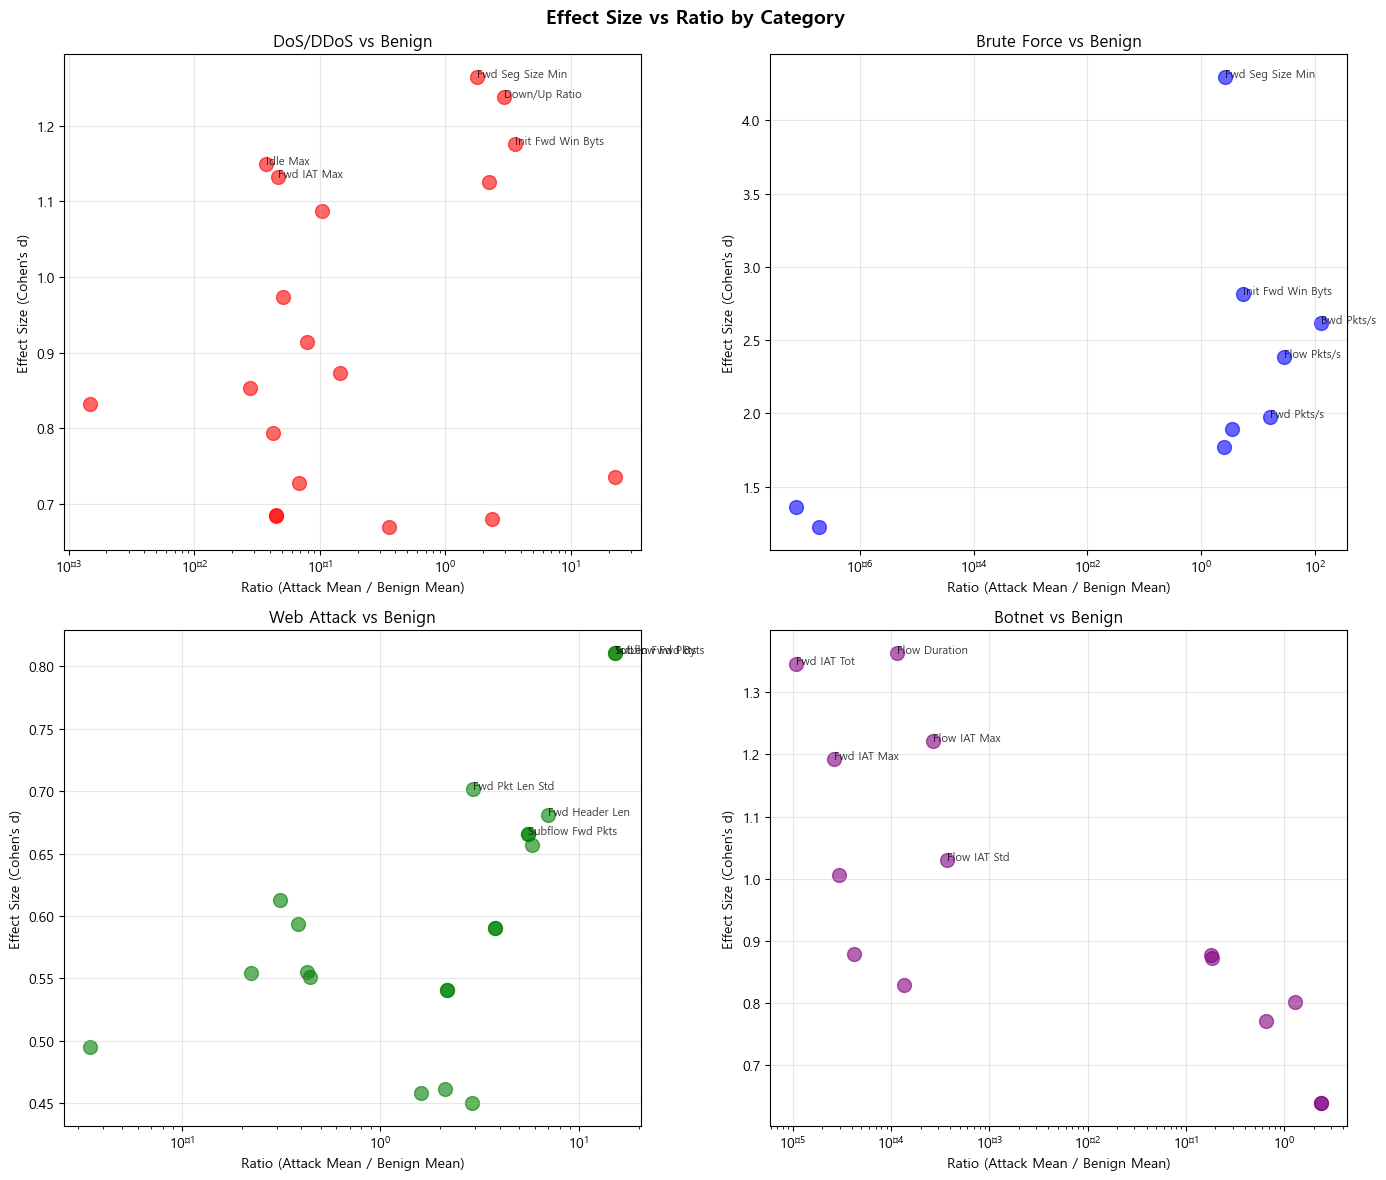

In [56]:
# Visualization 1: Effect Size vs Ratio Scatter Plot (4 categories in one figure)
print("Visualization 1: Effect Size vs Ratio Scatter Plot")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
colors = ['red', 'blue', 'green', 'purple']

for idx, category in enumerate(attack_categories):
    ax = axes[idx]
    data = all_significant[category].head(20).copy()  # Top 20

    # To use log scale, ratio must be greater than 0
    # Filter out invalid values (important!!)
    data = data[(data['ratio'] > 0) & np.isfinite(data['ratio']) & np.isfinite(data['cohens_d'])]

    # Terminal output
    print("\n" + "="*70)
    print(f"[{category}] Effect Size vs Ratio (Top Features)")
    print("="*70)
    print(f"{'Rank':>4} {'Feature':30s} {'Ratio (x)':>15s} {'Cohen d (y)':>15s}")
    print("-"*70)

    for i, (_, row) in enumerate(data.iterrows(), 1):
        print(f"{i:4d} {row['feature']:30s} {row['ratio']:15.6f} {row['cohens_d']:15.6f}")

    # Scatter plot
    ax.scatter(
        data['ratio'],
        data['cohens_d'],
        c=colors[idx],
        alpha=0.6,
        s=100
    )

    # Top 5 labels
    for _, row in data.head(5).iterrows():
        ax.annotate(
            row['feature'],
            (row['ratio'], row['cohens_d']),
            fontsize=8,
            alpha=0.8
        )

    ax.set_xlabel('Ratio (Attack Mean / Benign Mean)')
    ax.set_ylabel("Effect Size (Cohen's d)")
    ax.set_title(f'{category} vs Benign')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')  # Safe because only ratio > 0 values remain

plt.suptitle('Effect Size vs Ratio by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Dos/DDos
```text
1. Time-related features have very low ratio values => Idle Max, Fwd IAT Max < 0.1
-> Continuous packet transmission without pause (flooding)
2. Down/Up Ratio is very high
-> Attempting to receive many responses from the server (aimed at service disruption)
3. PSH Flag Cnt is very high
-> Many flags requesting immediate data delivery
4. Init Fwd Win Byts is high
-> Initial window size in the forward direction at TCP connection start is very large
5. Time-related (highly correlated): Idle Max, Fwd IAT Max, Flow IAT Max
-> Use Idle Max (highest Cohen's d value)

   IF Idle Max < threshold_low 
      AND Down/Up Ratio > threshold_high
      AND Init Fwd Win Byts > threshold_high
      THEN "DoS/DDoS"
```

### Brute Force
```text
=> Many factors to consider, further analysis to follow.
```

### Web Attack
```text
1. Subflow Fwd Byts (total bytes transmitted in the forward direction) is very large
-> In anomalous cases, hundreds to thousands of bytes
2. Fwd Header Len (sum of header lengths of forward direction packets) is large
-> Malicious code injected into HTTP headers
3. Fwd Pkt Len Std (standard deviation of forward direction packet lengths)
-> In web attacks, various attack attempts lead to diverse packet sizes

Limitations
   Detection Performance:
      - Effect Size: 0.5 ~ 0.81 (Medium)
      - Expected Accuracy: Lower compared to other categories
      - High likelihood of False Positives
   Causes
      - Flow-level data limitation: Cannot analyze payload content
      - Similar patterns to normal HTTP: SQL Injection, XSS also use HTTP request format
      - Insufficient samples: 743 instances (fewer than other categories)
   Recommendations
      - Detect Web Attack at "suspicious" level
      - Recommend combining with WAF (Web Application Firewall) for precise detection
      - Deep Packet Inspection required for payload analysis

   IF Subflow Fwd Byts > threshold
      AND Fwd Header Len > threshold
      AND Fwd Pkt Len Std > threshold
      THEN "Web Attack (Suspicious)"

```

### Botnet
```text
1. Time-related features are extremely low => Flow Duration (8,700x), Fwd IAT Tot (90,000x)
-> Very short connections
2. Packet size is small -> Pkt Len Mean
3. All IAT (Inter-Arrival Time) related features are low
-> Packet intervals are consistent and short
4. Difference from DDoS:
   DDoS    - Idle Max is low               -> Flooding
   Botnet  - Flow Duration is extremely low -> Short connections
5. Time-related (highly correlated): Flow Duration, Fwd IAT Tot, Flow IAT Max, Fwd IAT Max, Flow IAT Std, Fwd IAT Std
-> Flow Duration (d=1.36, highest), Fwd IAT Tot (d=1.34, highest among IAT features)

   IF Flow Duration < threshold_very_low
      AND Fwd IAT Tot < threshold_very_low
      AND Pkt Len Mean < threshold_low
      THEN "Botnet"


```

### Validation for Very Large Cohen's d - Brute Force: Fwd Seg Size Min
When the value is too large, reliability may decrease

In [66]:
benign = df[df['Category'] == 'Benign']
brute_force = df[df['Category'] == 'Brute Force']

# Validation 1: Check actual distribution statistics
feature = 'Fwd Seg Size Min'

print(f"[{feature}] Detailed Analysis")

benign_vals = benign[feature].dropna()
attack_vals = brute_force[feature].dropna()

print(f"\nBenign (n={len(benign_vals)}):")
print(f"  Mean: {benign_vals.mean():.2f}")
print(f"  Median: {benign_vals.median():.2f}")
print(f"  Std: {benign_vals.std():.2f}")
print(f"  Min: {benign_vals.min():.2f}")
print(f"  Max: {benign_vals.max():.2f}")
print(f"  Skewness: {benign_vals.skew():.2f}")

print(f"\nBrute Force (n={len(attack_vals)}):")
print(f"  Mean: {attack_vals.mean():.2f}")
print(f"  Median: {attack_vals.median():.2f}")
print(f"  Std: {attack_vals.std():.2f}")
print(f"  Min: {attack_vals.min():.2f}")
print(f"  Max: {attack_vals.max():.2f}")
print(f"  Skewness: {attack_vals.skew():.2f}")


# Validation 2: Cliff's Delta (Non-parametric Effect Size)
def cliffs_delta(x, y):
    """
    Calculate Cliff's Delta (non-parametric effect size)
    """
    n_x, n_y = len(x), len(y)
    
    # Compare all pairs
    greater = 0
    less = 0
    
    for xi in x:
        for yi in y:
            if xi > yi:
                greater += 1
            elif xi < yi:
                less += 1
    
    delta = (greater - less) / (n_x * n_y)
    return delta

# Sample if data is large (to save time)
sample_size = min(1000, len(benign_vals), len(attack_vals))
benign_sample = benign_vals.sample(n=sample_size, random_state=42)
attack_sample = attack_vals.sample(n=sample_size, random_state=42)

cliff_d = cliffs_delta(attack_sample.values, benign_sample.values)

print(f"\nEffect Size Comparison")
print(f"Cohen's d: 4.30")
print(f"Cliff's Delta: {cliff_d:.3f}")

if abs(cliff_d) > 0.474:
    print("  → Cliff's Delta is also Large! Reliable")
elif abs(cliff_d) > 0.33:
    print("  → Cliff's Delta is Medium. Cohen's d may be inflated")
else:
    print("  → Cliff's Delta is Small. Cohen's d is inflated!")


# Validation 3: Check distribution overlap
# Compare Benign max with Attack min
benign_max = benign_vals.quantile(0.95)  # Exclude top 5%
attack_min = attack_vals.quantile(0.05)  # Exclude bottom 5%

print(f"\nDistribution Overlap Check")
print(f"Benign 95th percentile: {benign_max:.2f}")
print(f"Attack 5th percentile: {attack_min:.2f}")

if attack_min > benign_max:
    print("  → Two distributions barely overlap! Reliable")
else:
    overlap_pct = (benign_vals > attack_min).mean() * 100
    print(f"  → Overlap ratio: {overlap_pct:.1f}%")
    if overlap_pct < 10:
        print("  → Low overlap. Reliable")
    else:
        print("  → High overlap. Caution needed")


# Validation 4: Bootstrap Confidence Interval
def bootstrap_cohens_d(x, y, n_bootstrap=1000):
    """
    Calculate Cohen's d confidence interval using Bootstrap
    """
    d_values = []
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        x_sample = np.random.choice(x, size=len(x), replace=True)
        y_sample = np.random.choice(y, size=len(y), replace=True)
        
        # Calculate Cohen's d
        pooled_std = np.sqrt((x_sample.std()**2 + y_sample.std()**2) / 2)
        if pooled_std > 0:
            d = abs(x_sample.mean() - y_sample.mean()) / pooled_std
            d_values.append(d)
    
    return np.percentile(d_values, [2.5, 97.5])

ci_low, ci_high = bootstrap_cohens_d(benign_sample.values, attack_sample.values)

print(f"\nCohen's d Confidence Interval (95%)")
print(f"Cohen's d: 4.30")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

ci_width = ci_high - ci_low
if ci_width < 1.0:
    print("  → Narrow confidence interval. Stable!")
else:
    print("  → Wide confidence interval. May be unstable")

[Fwd Seg Size Min] Detailed Analysis

Benign (n=11307):
  Mean: 15.41
  Median: 20.00
  Std: 8.09
  Min: 0.00
  Max: 48.00
  Skewness: -0.08

Brute Force (n=2324):
  Mean: 40.00
  Median: 40.00
  Std: 0.00
  Min: 40.00
  Max: 40.00
  Skewness: 0.00

Effect Size Comparison
Cohen's d: 4.30
Cliff's Delta: 0.996
  → Cliff's Delta is also Large! Reliable

Distribution Overlap Check
Benign 95th percentile: 32.00
Attack 5th percentile: 40.00
  → Two distributions barely overlap! Reliable

Cohen's d Confidence Interval (95%)
Cohen's d: 4.30
95% CI: [4.23, 4.61]
  → Narrow confidence interval. Stable!


Fwd Seg Size Min for Brute Force is exactly 40 across all samples<br>
Standard deviation = 0 (no variation)<br>
Skewness = 0 (perfectly symmetric, naturally, since there is only one value)

Cliff's Delta = 0.996<br>
= Brute Force values are greater than Benign values in 99.6% of comparisons<br>
= Brute Force > Benign in almost all comparisons<br>

Benign 95%: 32.00  (95% of Benign values are 32 or below)<br>
Attack 5%: 40.00   (Even the bottom 5% of Attack values are 40 or above)<br>
=> No overlap

Very simple and powerful rule<br>
IF Fwd Seg Size Min == 40 THEN "Brute Force (Suspicious)"

More lenient<br>
IF Fwd Seg Size Min > 35 THEN "Brute Force (Suspicious)"

### Brute Force - Key Feature Correlation Check
Check whether Bwd Pkts/s, Flow Pkts/s, and Fwd Pkts/s are redundant<br>
For Brute Force, many features have large Cohen's d values — using all of them risks overfitting, and missing even one leads to detection failure<br>
-> Remove redundant features after considering correlations

Part 1: Brute Force - Key Feature Correlation


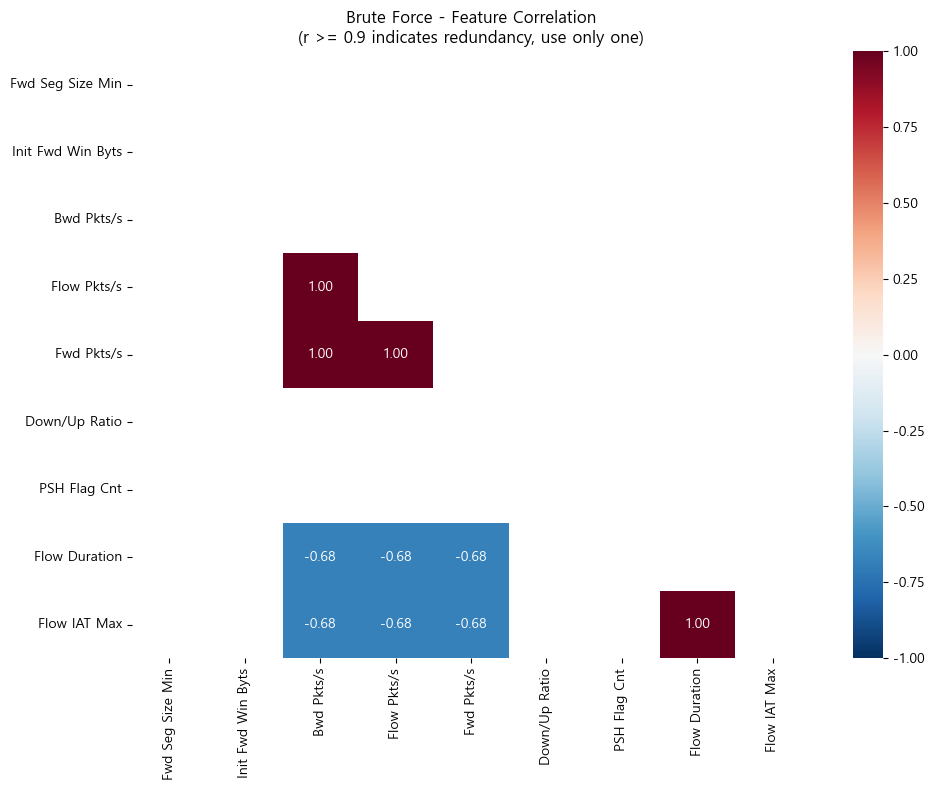


High correlations (|r| > 0.8):
  Bwd Pkts/s ↔ Flow Pkts/s: 1.000
  Bwd Pkts/s ↔ Fwd Pkts/s: 1.000
  Flow Pkts/s ↔ Fwd Pkts/s: 1.000
  Flow Duration ↔ Flow IAT Max: 1.000


In [68]:
print("Part 1: Brute Force - Key Feature Correlation")

brute_force = df[df['Category'] == 'Brute Force']

# Features to analyze
bf_features = [
    'Fwd Seg Size Min', 'Init Fwd Win Byts', 'Bwd Pkts/s', 
    'Flow Pkts/s', 'Fwd Pkts/s', 'Down/Up Ratio', 
    'PSH Flag Cnt', 'Flow Duration', 'Flow IAT Max'
]

# Select only existing features
bf_features = [f for f in bf_features if f in df.columns]

# Calculate correlation
corr_matrix = brute_force[bf_features].corr()

# Visualization
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Brute Force - Feature Correlation\n(r >= 0.9 indicates redundancy, use only one)')
plt.tight_layout()
plt.show()

# Print high correlations
print("\nHigh correlations (|r| > 0.8):")
for i in range(len(bf_features)):
    for j in range(i+1, len(bf_features)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            print(f"  {bf_features[i]} ↔ {bf_features[j]}: {corr_val:.3f}")

```text
Transmission rate features: All three carry identical information (Bwd Pkts, Flow Pkts, Fwd Pkts)
=> Use Bwd Pkts/s

Time-related features: Both carry identical information (Flow Duration, Flow IAT Max)
=> Use Flow Duration


   IF Fwd Seg Size Min > threshold
      AND Bwd Pkts/s > threshold
      AND Flow Duration < threshold
      AND Init Fwd Win Byts > threshold
      AND Down/Up Ratio > threshold
      AND PSH Flag Cnt > threshold
   THEN "Brute Force"
```

Visualization 2: Benign Percentile Plot
Top 10 Features to analyze: ['Idle Max', 'Flow IAT Max', 'Idle Mean', 'Fwd Seg Size Min', 'Down/Up Ratio', 'Init Fwd Win Byts', 'Fwd IAT Max', 'PSH Flag Cnt', 'Fwd IAT Std', 'Flow IAT Std']


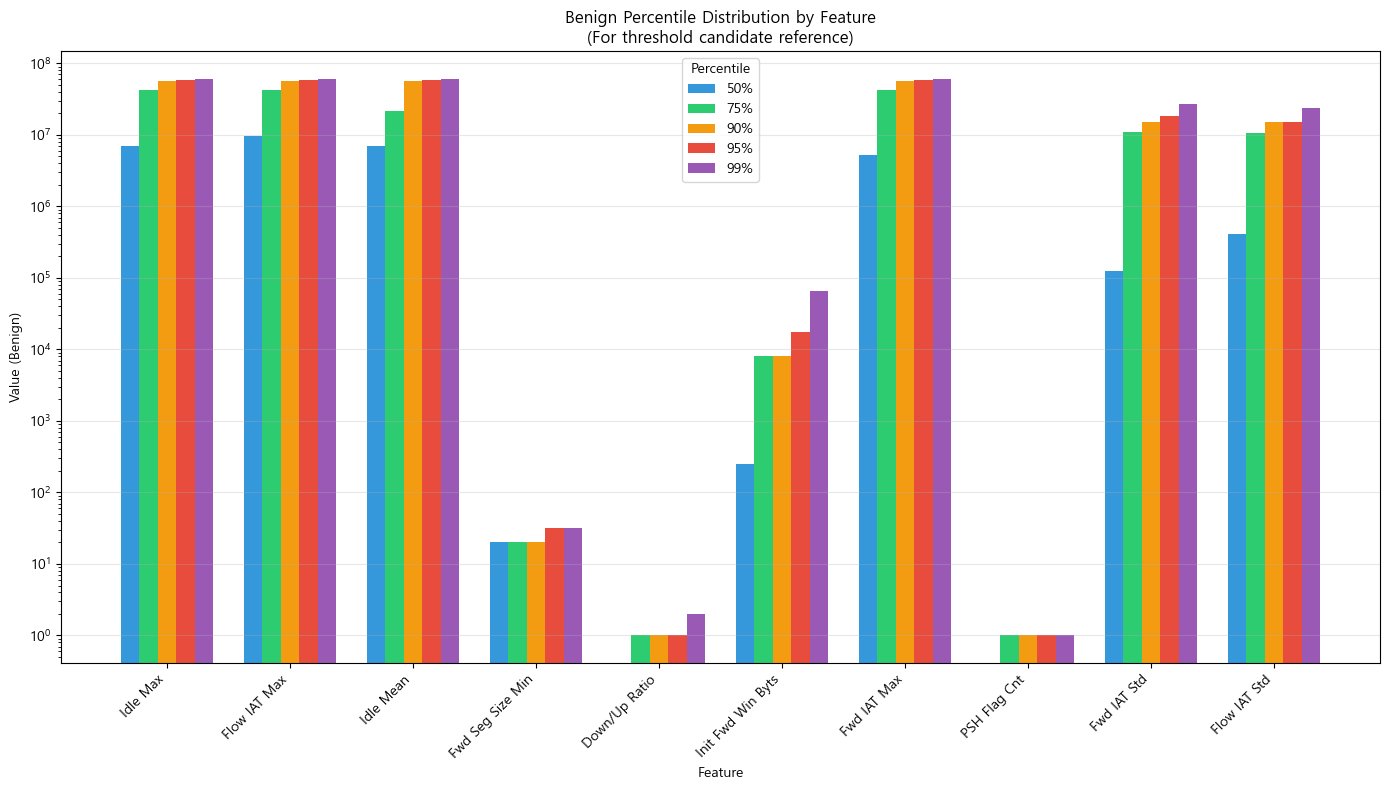

In [69]:
# Visualization 2: Benign Percentile Plot (Top 10 Features)
print("Visualization 2: Benign Percentile Plot")

# Select Top 10 features commonly important across all categories
all_top_features = []
for category in attack_categories:
    top_feats = all_significant[category].head(10)['feature'].tolist()
    all_top_features.extend(top_feats)

# Select features that appear most frequently
from collections import Counter
feature_counts = Counter(all_top_features)
top_10_features = [feat for feat, count in feature_counts.most_common(10)]

print(f"Top 10 Features to analyze: {top_10_features}")

# Calculate percentiles
percentiles = [50, 75, 90, 95, 99]
percentile_data = []

for feat in top_10_features:
    feat_data = benign[feat].dropna()
    for p in percentiles:
        percentile_data.append({
            'feature': feat,
            'percentile': p,
            'value': np.percentile(feat_data, p)
        })

percentile_df = pd.DataFrame(percentile_data)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_10_features))
width = 0.15
colors_p = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for i, p in enumerate(percentiles):
    values = percentile_df[percentile_df['percentile'] == p]['value'].values
    bars = ax.bar(x + i*width, values, width, label=f'{p}%', color=colors_p[i])

ax.set_xlabel('Feature')
ax.set_ylabel('Value (Benign)')
ax.set_title('Benign Percentile Distribution by Feature\n(For threshold candidate reference)')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(top_10_features, rotation=45, ha='right')
ax.legend(title='Percentile')
ax.set_yscale('log')  # Log scale for large value ranges
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Visualization 3: Feature Correlation Heatmap (Benign-based)


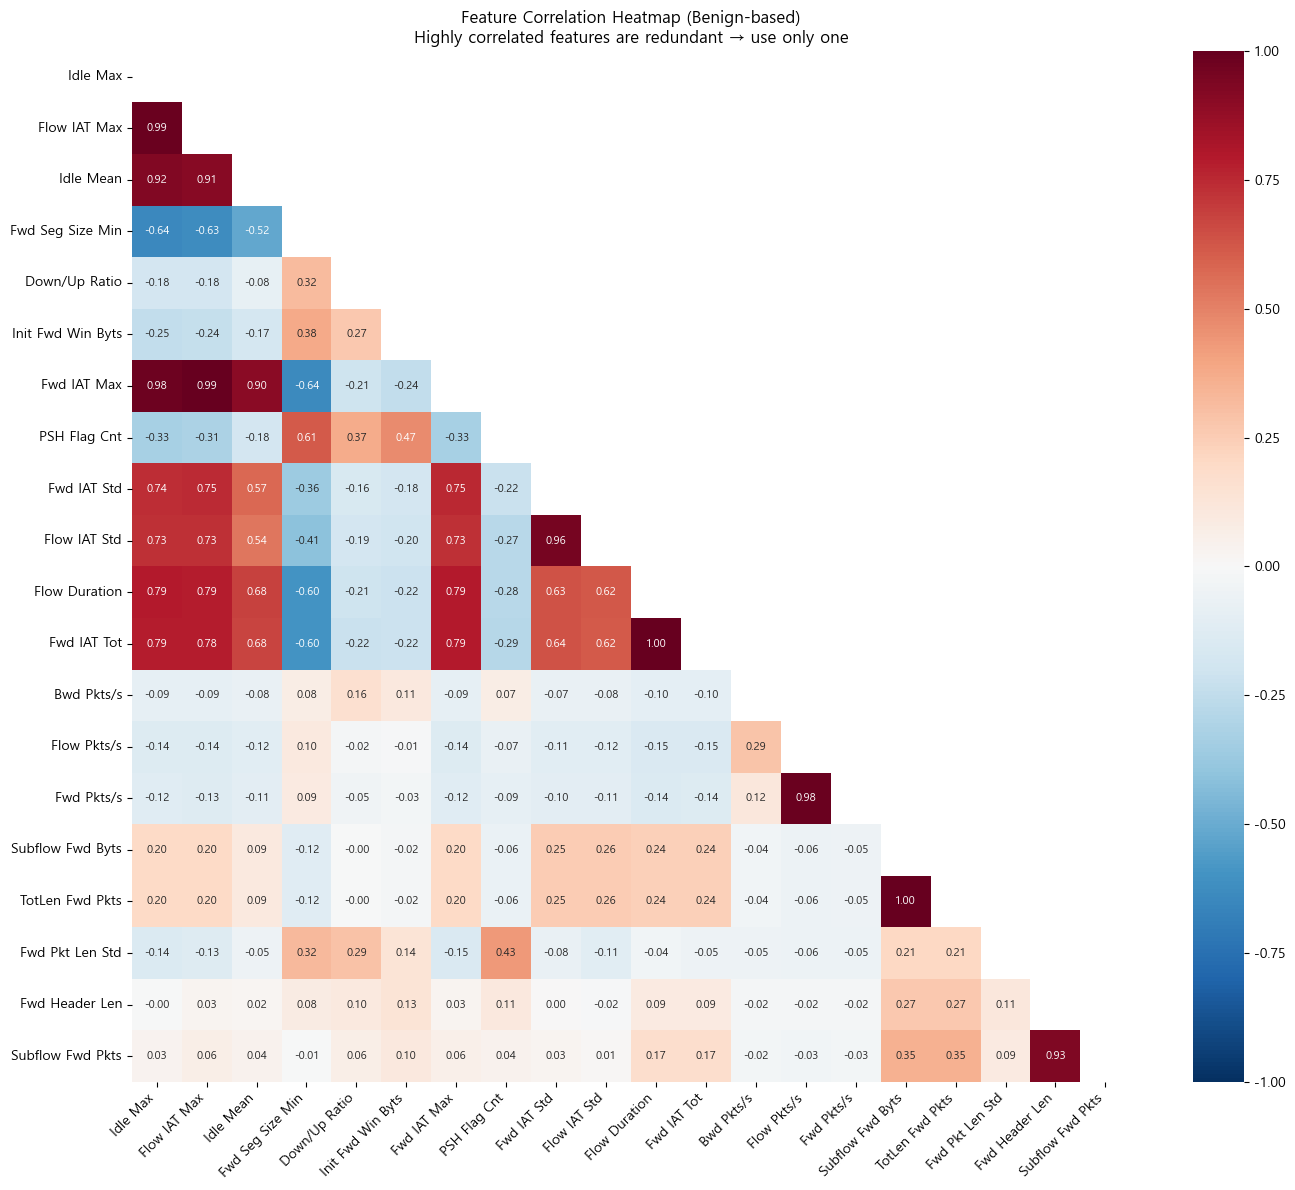

In [70]:
# Visualization 3: Feature Correlation Heatmap (Benign-based, Top 20)
print("Visualization 3: Feature Correlation Heatmap (Benign-based)")

# Select Top 20 features
top_20_features = [feat for feat, count in feature_counts.most_common(20)]

# Calculate correlation on Benign data
corr_data = benign[top_20_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_data, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Feature Correlation Heatmap (Benign-based)\nHighly correlated features are redundant → use only one', 
             fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Visualization 4: Top Feature Bar Chart by Category


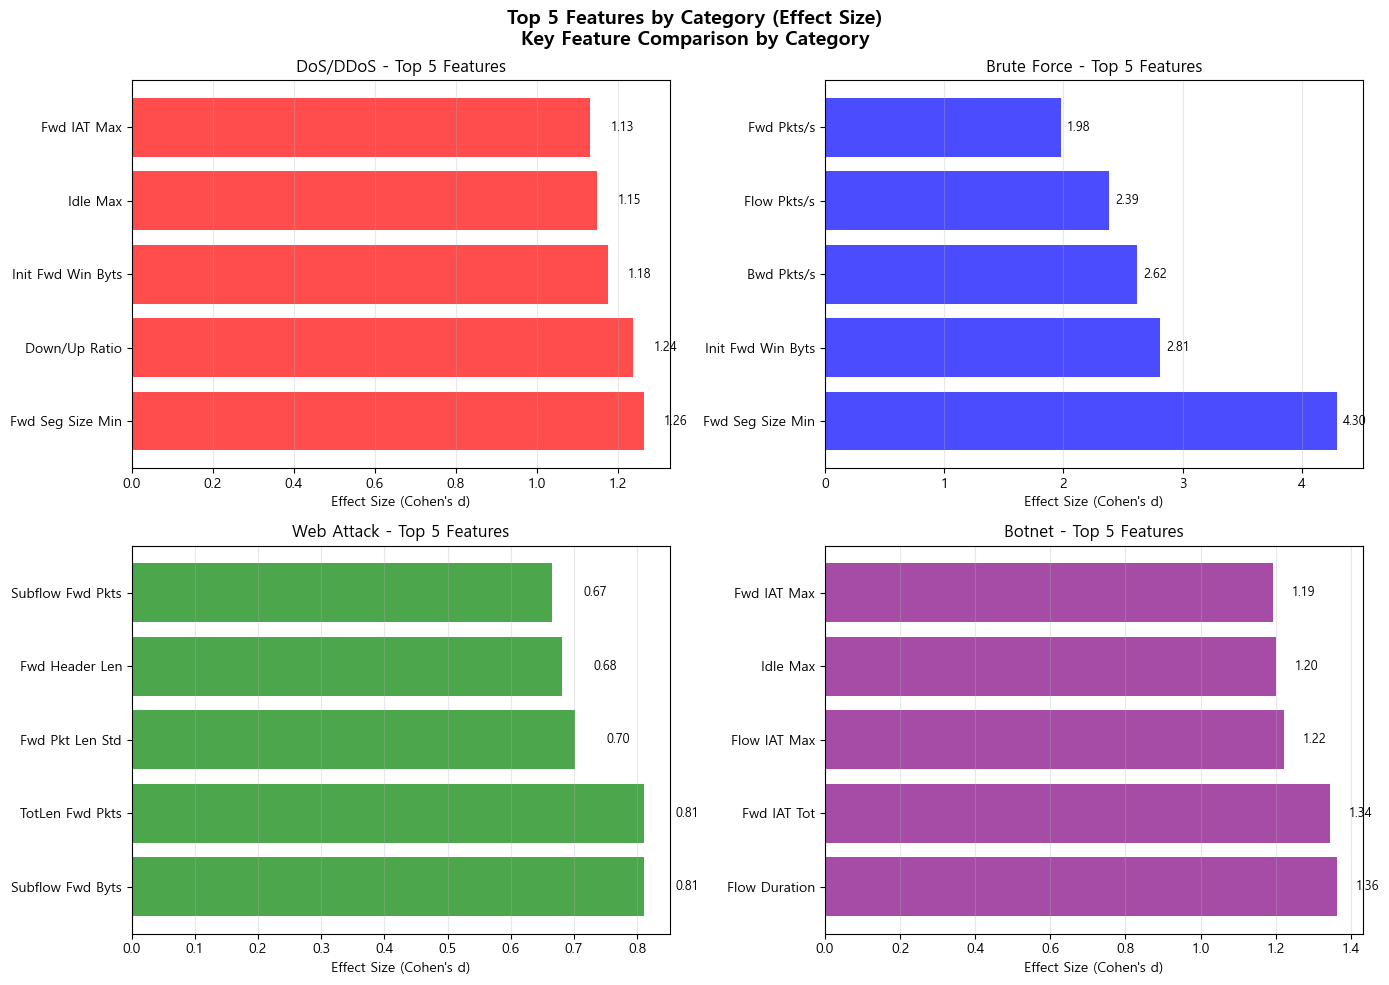

In [74]:
# Visualization 4: Top 5 Feature Bar Chart by Category (Effect Size)
print("Visualization 4: Top Feature Bar Chart by Category")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['red', 'blue', 'green', 'purple']

for idx, category in enumerate(attack_categories):
    ax = axes[idx]
    top5 = all_significant[category].head(5)
    
    bars = ax.barh(range(len(top5)), top5['cohens_d'].values, color=colors[idx], alpha=0.7)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5['feature'].values)
    ax.set_xlabel('Effect Size (Cohen\'s d)')
    ax.set_title(f'{category} - Top 5 Features')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Display values
    for i, (bar, val) in enumerate(zip(bars, top5['cohens_d'].values)):
        ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Top 5 Features by Category (Effect Size)\nKey Feature Comparison by Category', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
print("Analysis Summary")

print("\n[Top 5 Features by Category]")
for category in attack_categories:
    print(f"\n{category}:")
    top5 = all_significant[category].head(5)
    for i, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"  {i}. {row['feature']} (Effect Size: {row['cohens_d']:.2f}, Ratio: {row['ratio']:.1f}x)")

print("\n[Common Top Features]")
print("Features frequently appearing across all categories:")
for feat, count in feature_counts.most_common(10):
    print(f"  - {feat}: Top 10 in {count} categories")


Analysis Summary

[Top 5 Features by Category]

DoS/DDoS:
  1. Fwd Seg Size Min (Effect Size: 1.26, Ratio: 1.8x)
  2. Down/Up Ratio (Effect Size: 1.24, Ratio: 2.9x)
  3. Init Fwd Win Byts (Effect Size: 1.18, Ratio: 3.6x)
  4. Idle Max (Effect Size: 1.15, Ratio: 0.0x)
  5. Fwd IAT Max (Effect Size: 1.13, Ratio: 0.0x)

Brute Force:
  1. Fwd Seg Size Min (Effect Size: 4.30, Ratio: 2.6x)
  2. Init Fwd Win Byts (Effect Size: 2.81, Ratio: 5.4x)
  3. Bwd Pkts/s (Effect Size: 2.62, Ratio: 128.9x)
  4. Flow Pkts/s (Effect Size: 2.39, Ratio: 29.2x)
  5. Fwd Pkts/s (Effect Size: 1.98, Ratio: 16.5x)

Web Attack:
  1. Subflow Fwd Byts (Effect Size: 0.81, Ratio: 15.3x)
  2. TotLen Fwd Pkts (Effect Size: 0.81, Ratio: 15.3x)
  3. Fwd Pkt Len Std (Effect Size: 0.70, Ratio: 2.9x)
  4. Fwd Header Len (Effect Size: 0.68, Ratio: 7.0x)
  5. Subflow Fwd Pkts (Effect Size: 0.67, Ratio: 5.6x)

Botnet:
  1. Flow Duration (Effect Size: 1.36, Ratio: 0.0x)
  2. Fwd IAT Tot (Effect Size: 1.34, Ratio: 0.0x)
  3. Flo